## Symulacja kolejki M/M/c - Izba przyjęć szpital
 - λ = 8 (częstotliwość pacjentów na godzinę)
 - μ = 3 (ilość obsłużonych pacjentów na godzinę przez lekarza)
 - c = 3 (ilość lekarzy)
 - Symulacja dla 100 dni
 - Około 200 pacjentów dziennie

### 1. Import bibliotek i definicja klas

In [33]:
import random
import csv
import heapq
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Optional

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

### 2. Definicje klas pomocniczych - pacjent i doktor

In [34]:
class Patient:
    """Klasa reprezentująca pacjenta w systemie"""
    id: int
    arrival_time: float
    queue_length_on_arrival: int
    service_start_time: Optional[float] = None
    service_end_time: Optional[float] = None
    waiting_time: Optional[float] = None
    doctor_id: Optional[int] = None
    day: Optional[int] = None

    def __init__(self, id: int, arrival_time: float, queue_length_on_arrival: int):
        self.id = id
        self.arrival_time = arrival_time
        self.queue_length_on_arrival = queue_length_on_arrival
        self.service_start_time = None
        self.service_end_time = None
        self.waiting_time = None
        self.doctor_id = None
        self.day = None

class Doctor:
    """Klasa reprezentująca lekarza"""
    id: int
    is_busy: bool = False
    current_patient: Optional[Patient] = None
    next_free_time: float = 0.0

    def __init__(self, id: int):
        self.id = id
        self.is_busy = False
        self.current_patient = None
        self.next_free_time = 0.0

### 3. Definicje klasy symulacji

In [35]:
class MMcQueueSimulation:
    """Symulacja kolejki M/M/c dla izby przyjęć szpitala"""
    
    def __init__(self, lambda_rate: float, mu_rate: float, num_doctors: int):
        self.lambda_rate = lambda_rate  # średnia liczba pacjentów na godzinę
        self.mu_rate = mu_rate          # średnia liczba pacjentów obsłużonych przez lekarza na godzinę
        self.num_doctors = num_doctors  # liczba lekarzy
        self.doctors = [Doctor(i+1) for i in range(num_doctors)]
        self.queue = []                 # kolejka oczekujących pacjentów
        self.event_queue = []           # kolejka zdarzeń (arrival, departure)
        self.current_time = 0.0
        self.patient_counter = 0
        self.completed_patients = []
        
    def generate_interarrival_time(self) -> float:
        """Generuje czas między kolejnymi przyjściami (rozkład wykładniczy)"""
        return random.expovariate(self.lambda_rate)
    
    def generate_service_time(self) -> float:
        """Generuje czas obsługi pacjenta (rozkład wykładniczy)"""
        return random.expovariate(self.mu_rate)
    
    def get_next_free_doctor(self) -> Optional[Doctor]:
        """Zwraca pierwszego wolnego lekarza lub None jeśli wszyscy są zajęci"""
        for doctor in self.doctors:
            if not doctor.is_busy:
                return doctor
        return None
    
    def get_free_doctors(self) -> List[Doctor]:
        """Zwraca listę wszystkich wolnych lekarzy"""
        return [doctor for doctor in self.doctors if not doctor.is_busy]
    
    def get_random_free_doctor(self) -> Optional[Doctor]:
        """Zwraca losowo wybranego wolnego lekarza"""
        free_doctors = self.get_free_doctors()
        if free_doctors:
            return random.choice(free_doctors)
        return None
    
    def schedule_arrival(self, time: float, target_patients: int):
        """Planuje przyjście pacjenta"""
        if self.patient_counter < target_patients:
            heapq.heappush(self.event_queue, (time, 'arrival', None))
    
    def schedule_departure(self, time: float, doctor: Doctor):
        """Planuje zakończenie obsługi pacjenta"""
        heapq.heappush(self.event_queue, (time, 'departure', doctor))
    
    def process_arrival(self, target_patients: int):
        """Przetwarza przyjście pacjenta"""
        if self.patient_counter >= target_patients:
            return
            
        self.patient_counter += 1
        patient = Patient(
            id=self.patient_counter,
            arrival_time=self.current_time,
            queue_length_on_arrival=len(self.queue)
        )
        
        # Sprawdź czy jest wolny lekarz
        free_doctor = self.get_random_free_doctor()
        
        if free_doctor:
            # Rozpocznij obsługę natychmiast
            self.start_service(patient, free_doctor)
        else:
            # Dodaj do kolejki
            self.queue.append(patient)
        
        # Zaplanuj następne przyjście
        next_arrival_time = self.current_time + self.generate_interarrival_time()
        self.schedule_arrival(next_arrival_time, target_patients)
    
    def start_service(self, patient: Patient, doctor: Doctor):
        """Rozpoczyna obsługę pacjenta przez lekarza"""
        patient.service_start_time = self.current_time
        patient.waiting_time = self.current_time - patient.arrival_time
        patient.doctor_id = doctor.id
        
        doctor.is_busy = True
        doctor.current_patient = patient
        
        service_time = self.generate_service_time()
        service_end_time = self.current_time + service_time
        patient.service_end_time = service_end_time
        doctor.next_free_time = service_end_time
        
        # Zaplanuj zakończenie obsługi
        self.schedule_departure(service_end_time, doctor)
    
    def process_departure(self, doctor: Doctor):
        """Przetwarza zakończenie obsługi pacjenta"""
        if doctor.current_patient:
            completed_patient = doctor.current_patient
            self.completed_patients.append(completed_patient)
            
            doctor.is_busy = False
            doctor.current_patient = None
            
            # Jeśli są pacjenci w kolejce, rozpocznij obsługę następnego
            if self.queue:
                next_patient = self.queue.pop(0)
                self.start_service(next_patient, doctor)
    
    def run_single_day_simulation(self, day: int, target_patients: int = 150) -> List[Patient]:
        """Uruchamia symulację dla jednego dnia"""
        # Reset symulacji
        self.current_time = 0.0
        self.patient_counter = 0
        self.completed_patients = []
        self.queue = []
        self.event_queue = []
        
        # Reset lekarzy
        for doctor in self.doctors:
            doctor.is_busy = False
            doctor.current_patient = None
            doctor.next_free_time = 0.0
        
        # Zaplanuj pierwsze przyjście
        first_arrival_time = self.generate_interarrival_time()
        self.schedule_arrival(first_arrival_time, target_patients)
        
        # Główna pętla symulacji
        while self.event_queue and len(self.completed_patients) < target_patients:
            # Pobierz następne zdarzenie
            event_time, event_type, doctor = heapq.heappop(self.event_queue)
            self.current_time = event_time
            
            if event_type == 'arrival':
                self.process_arrival(target_patients)
            elif event_type == 'departure':
                self.process_departure(doctor)
        
        # Dodaj numer dnia do wszystkich pacjentów
        for patient in self.completed_patients:
            patient.day = day
        
        return self.completed_patients.copy()

### 4. Definicja funkcji służących do uruchomienia symulacji dla 100 dni i zebrania wyników

In [36]:
def run_full_simulation(days: int, lambda_rate: float, 
                       mu_rate: float, num_doctors: int) -> List[Patient]:
    
    simulation = MMcQueueSimulation(lambda_rate, mu_rate, num_doctors)
    all_patients = []
    
    print(f"Rozpoczynam symulację dla {days} dni...")
    print(f"Parametry: λ={lambda_rate}/h, μ={mu_rate}/h, c={num_doctors}")
    
    for day in range(1, days + 1):
        # Losowa liczba pacjentów w podanym przedziale
        target_patients = random.randint(200, 210)
        
        day_patients = simulation.run_single_day_simulation(day, target_patients)
        sorted_day_patients = sorted(day_patients, key=lambda p: p.arrival_time)#[20:]
        all_patients.extend(sorted_day_patients)
        
    
    print(f"Symulacja zakończona. Łącznie obsłużono {len(all_patients)} pacjentów.")
    return all_patients

def save_results_to_csv(patients: List[Patient], filename):
    
    # Sortowanie pacjentów według ID
    
    with open(filename, 'w', newline='', encoding='utf-8') as csvfile:
        fieldnames = ['ID', 'Czas_przyjscia', 'Dlugosc_kolejki_w_momencie_przyjscia', 
                     'Czas_rozpoczecia_badania', 'Czas_zakonczenia_badania', 
                     'Czas_oczekiwania', 'Dzien', 'Lekarz']
        
        writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
        writer.writeheader()
        
        for idx,patient in enumerate(patients):
            writer.writerow({
                'ID': idx + 1,
                'Czas_przyjscia': patient.arrival_time * 60,  
                'Dlugosc_kolejki_w_momencie_przyjscia': patient.queue_length_on_arrival,
                'Czas_rozpoczecia_badania': patient.service_start_time * 60,  
                'Czas_zakonczenia_badania': patient.service_end_time * 60,  
                'Czas_oczekiwania': patient.waiting_time * 60,  
                'Dzien': patient.day,
                'Lekarz': patient.doctor_id
            })
    
    print(f"Wyniki zapisano do pliku: {filename}")

### 5. Uruchomienie symulacji i zapisanie wyników do CSV

In [37]:
filename = 'wyniki_symulacji.csv'

#random.seed(42)

LAMBDA = 8   # pacjenci na godzinę
MU = 3        # pacjenci obsłużeni przez lekarza na godzinę  
C = 3         # liczba lekarzy
DAYS = 100    # liczba dni symulacji


all_patients = run_full_simulation(
    days=DAYS, 
    lambda_rate=LAMBDA, 
    mu_rate=MU, 
    num_doctors=C
)


save_results_to_csv(all_patients,filename)

Rozpoczynam symulację dla 100 dni...
Parametry: λ=8/h, μ=3/h, c=3
Symulacja zakończona. Łącznie obsłużono 20414 pacjentów.
Wyniki zapisano do pliku: wyniki_symulacji.csv


### 6. Podstawowa analiza wyników

In [38]:
data = []
for patient in all_patients:
    data.append({
        'ID': patient.id,
        'Czas_przyjscia_min': round(patient.arrival_time * 60),
        'Dlugosc_kolejki': patient.queue_length_on_arrival,
        'Czas_rozpoczecia_min': round(patient.service_start_time * 60),
        'Czas_zakonczenia_min': round(patient.service_end_time * 60),
        'Czas_oczekiwania_min': round(patient.waiting_time * 60),
        'Dzien': patient.day,
        'Lekarz': patient.doctor_id
    })

df = pd.DataFrame(data)

In [39]:
print("="*60)
print("SZCZEGÓŁOWA ANALIZA WYNIKÓW SYMULACJI")
print("="*60)

# Podstawowe statystyki
total_patients = len(df)
avg_waiting_time = df['Czas_oczekiwania_min'].mean()
std_waiting_time = df['Czas_oczekiwania_min'].std()
max_waiting_time = df['Czas_oczekiwania_min'].max()

avg_queue_length = df['Dlugosc_kolejki'].mean()
max_queue_length = df['Dlugosc_kolejki'].max()

days = df['Dzien'].nunique()
patients_per_day = df.groupby('Dzien').size()

print(f"Łączna liczba pacjentów: {total_patients}")
print(f"Liczba dni symulacji: {days}")
print(f"Średnia liczba pacjentów dziennie: {patients_per_day.mean():.1f}")
print(f"Min/Max pacjentów dziennie: {patients_per_day.min()}/{patients_per_day.max()}")
print()

print("CZASY OCZEKIWANIA:")
print(f"Średni czas oczekiwania: {avg_waiting_time:.1f} minut")
print(f"Odchylenie standardowe: {std_waiting_time:.1f} minut")
print(f"Maksymalny czas oczekiwania: {max_waiting_time} minut")
print(f"Mediana czasu oczekiwania: {df['Czas_oczekiwania_min'].median():.1f} minut")
print()

print("DŁUGOŚĆ KOLEJKI:")
print(f"Średnia długość kolejki przy przyjściu: {avg_queue_length:.2f}")
print(f"Maksymalna długość kolejki: {max_queue_length}")
print(f"% pacjentów obsłużonych od razu: {(df['Dlugosc_kolejki'] == 0).mean() * 100:.1f}%")
print()

# Statystyki per lekarz
doctor_stats = df.groupby('Lekarz').agg({
    'ID': 'count',
    'Czas_oczekiwania_min': 'mean'
}).round(2)
doctor_stats.columns = ['Liczba_pacjentow', 'Sredni_czas_oczekiwania']
print("STATYSTYKI PER LEKARZ:")
print(doctor_stats)

# Współczynnik wykorzystania
rho = LAMBDA / (C * MU)
print(f"\nWspółczynnik wykorzystania (ρ): {rho:.3f}")

SZCZEGÓŁOWA ANALIZA WYNIKÓW SYMULACJI
Łączna liczba pacjentów: 20414
Liczba dni symulacji: 100
Średnia liczba pacjentów dziennie: 204.1
Min/Max pacjentów dziennie: 200/210

CZASY OCZEKIWANIA:
Średni czas oczekiwania: 31.9 minut
Odchylenie standardowe: 42.3 minut
Maksymalny czas oczekiwania: 319 minut
Mediana czasu oczekiwania: 16.0 minut

DŁUGOŚĆ KOLEJKI:
Średnia długość kolejki przy przyjściu: 4.03
Maksymalna długość kolejki: 40
% pacjentów obsłużonych od razu: 38.8%

STATYSTYKI PER LEKARZ:
        Liczba_pacjentow  Sredni_czas_oczekiwania
Lekarz                                           
1                   6774                    31.12
2                   6856                    32.37
3                   6784                    32.12

Współczynnik wykorzystania (ρ): 0.889


### 7. Wizualizacje

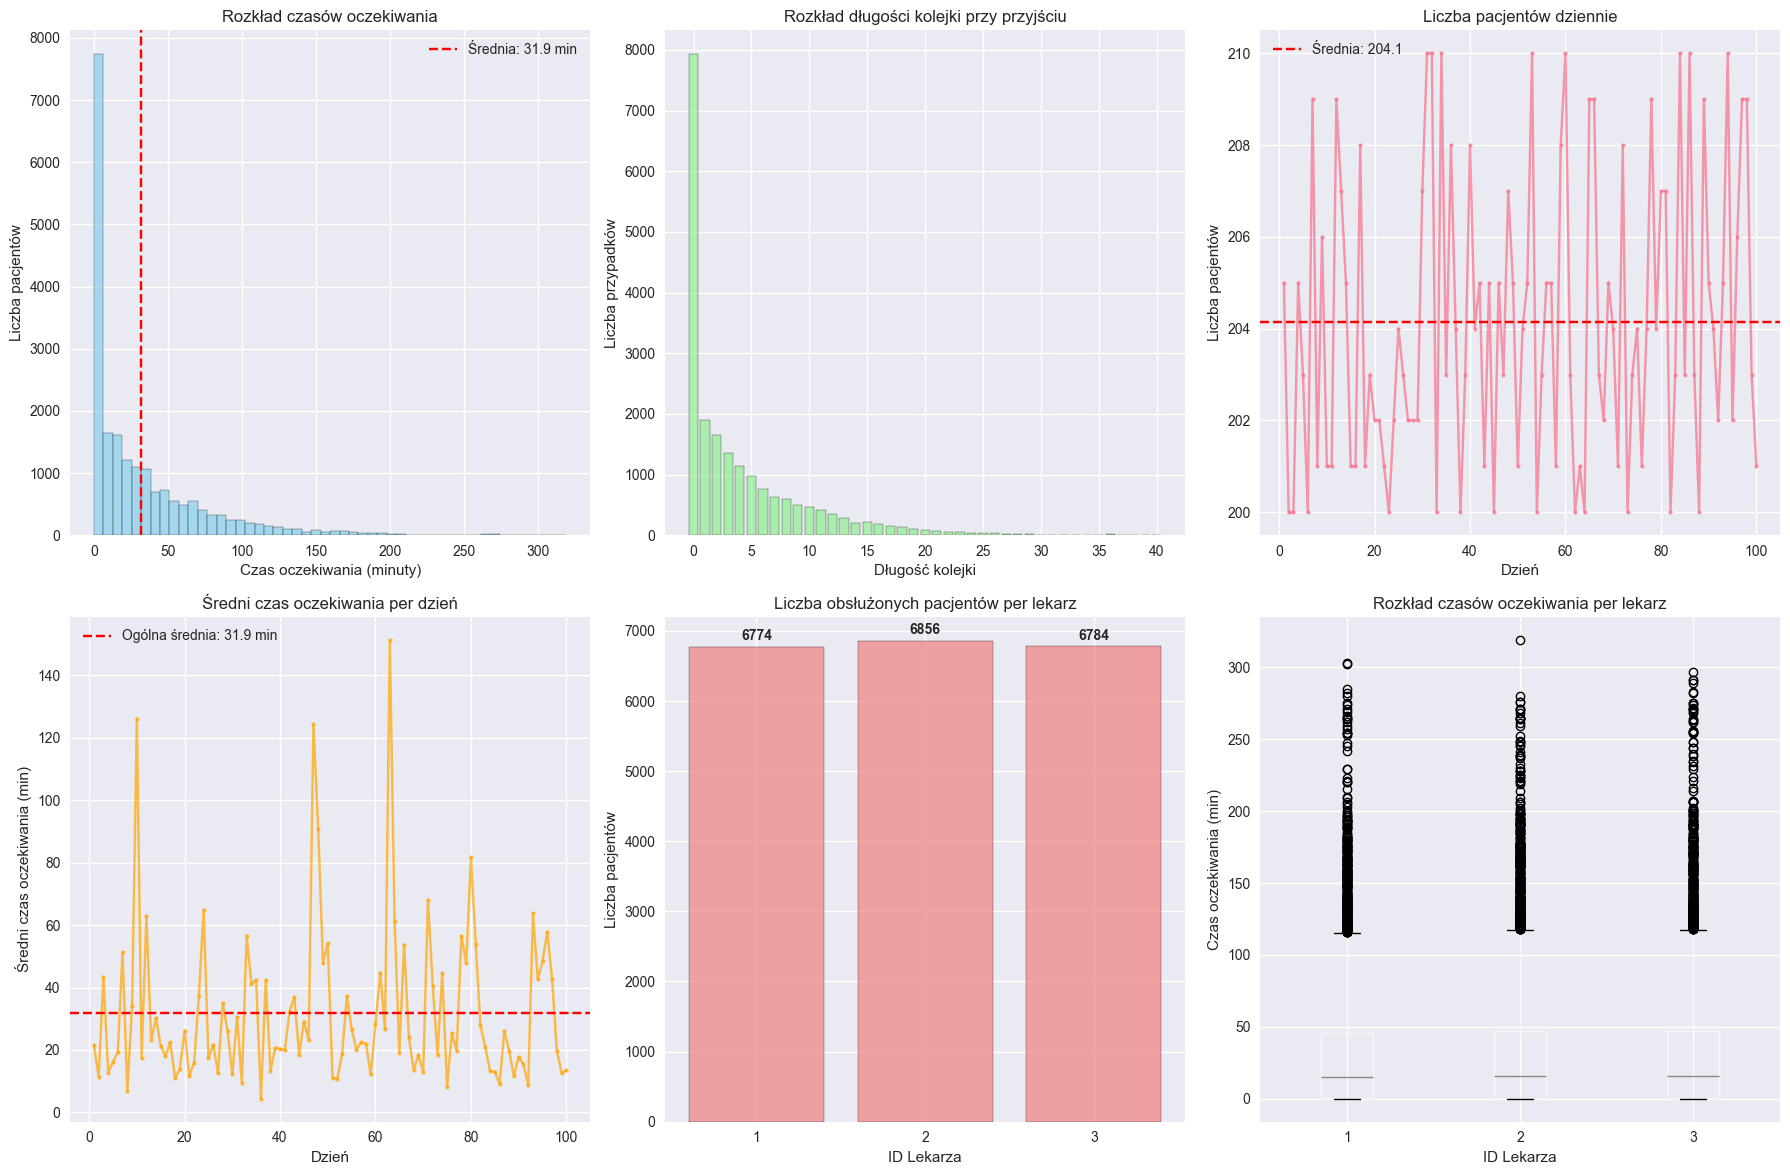

In [40]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Histogram czasów oczekiwania
axes[0, 0].hist(df['Czas_oczekiwania_min'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Rozkład czasów oczekiwania')
axes[0, 0].set_xlabel('Czas oczekiwania (minuty)')
axes[0, 0].set_ylabel('Liczba pacjentów')
axes[0, 0].axvline(df['Czas_oczekiwania_min'].mean(), color='red', linestyle='--', 
                   label=f'Średnia: {df["Czas_oczekiwania_min"].mean():.1f} min')
axes[0, 0].legend()

# 2. Histogram długości kolejki
queue_counts = df['Dlugosc_kolejki'].value_counts().sort_index()
axes[0, 1].bar(queue_counts.index, queue_counts.values, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Rozkład długości kolejki przy przyjściu')
axes[0, 1].set_xlabel('Długość kolejki')
axes[0, 1].set_ylabel('Liczba przypadków')

# 3. Liczba pacjentów per dzień
daily_patients = df.groupby('Dzien').size()
axes[0, 2].plot(daily_patients.index, daily_patients.values, marker='o', markersize=3, alpha=0.7)
axes[0, 2].set_title('Liczba pacjentów dziennie')
axes[0, 2].set_xlabel('Dzień')
axes[0, 2].set_ylabel('Liczba pacjentów')
axes[0, 2].axhline(daily_patients.mean(), color='red', linestyle='--', 
                   label=f'Średnia: {daily_patients.mean():.1f}')
axes[0, 2].legend()

# 4. Średni czas oczekiwania per dzień
daily_waiting = df.groupby('Dzien')['Czas_oczekiwania_min'].mean()
axes[1, 0].plot(daily_waiting.index, daily_waiting.values, marker='o', markersize=3, alpha=0.7, color='orange')
axes[1, 0].set_title('Średni czas oczekiwania per dzień')
axes[1, 0].set_xlabel('Dzień')
axes[1, 0].set_ylabel('Średni czas oczekiwania (min)')
axes[1, 0].axhline(daily_waiting.mean(), color='red', linestyle='--', 
                   label=f'Ogólna średnia: {daily_waiting.mean():.1f} min')
axes[1, 0].legend()

# 5. Obciążenie lekarzy
doctor_workload = df['Lekarz'].value_counts().sort_index()
axes[1, 1].bar(doctor_workload.index, doctor_workload.values, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1, 1].set_xticks(doctor_workload.index)
axes[1, 1].set_title('Liczba obsłużonych pacjentów per lekarz')
axes[1, 1].set_xlabel('ID Lekarza')
axes[1, 1].set_ylabel('Liczba pacjentów')
for i, v in enumerate(doctor_workload.values):
    axes[1, 1].text(i+1, v+50, str(v), ha='center', va='bottom', fontweight='bold')

# 6. Boxplot czasów oczekiwania per lekarz
df.boxplot(column='Czas_oczekiwania_min', by='Lekarz', ax=axes[1, 2])
axes[1, 2].set_title('Rozkład czasów oczekiwania per lekarz')
axes[1, 2].set_xlabel('ID Lekarza')
axes[1, 2].set_ylabel('Czas oczekiwania (min)')
plt.suptitle('') 

plt.tight_layout()
plt.show()